In [275]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import csv, json
from sklearn.metrics import root_mean_squared_error,mean_squared_error
import numpy as np

from statsmodels.stats.weightstats import ttost_ind
import statsmodels.formula.api as smf
import statsmodels.api as sm
# use the dedicated RMSE function (sklearn ≥1.4)
from sklearn.metrics import root_mean_squared_error
import sys, inspect, sklearn, sklearn.metrics as M


In [277]:
# !pip install statsmodels

In [279]:

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("Signature:", inspect.signature(M.mean_squared_error))
print("From module:", M.mean_squared_error.__module__)
print("Kernel executable:", sys.executable)

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]
scikit-learn: 1.5.1
Signature: (y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', squared='deprecated')
From module: sklearn.metrics._regression
Kernel executable: /opt/anaconda3/bin/python


# Read me

This script relies on the data being chunked by "DataChunking_sigmark_overheadtest.ipynb" and that we have obtained one csv file for each of the tests. If in doubt, check your "ChunkedData" folder.

The following imports the chunked data and provides us with two dataframes:
- dfs which holds the energy data for all the test
- df_powers holds all the power measurements for all the tests

After the import, the data is ready for your 

In [282]:
input_directory = '../ChunkedData_Siglent'
output_directory = '../Results/'

In [284]:
# this part reads the chunked data files related to the 

In [315]:
ls ../ChunkedData_Siglent

sigmark_0.01_1764769841716_10_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764770965065_21_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764772088504_32_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764773211840_43_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764774335186_54_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764775458525_65_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764776581842_76_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764777705166_87_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764778828505_98_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv
sigmark_0.01_1764779951853_109_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv

In [317]:
test_file = "../ChunkedData_Siglent/sigmark_0.01_1764861092477_159_20_siglent.1764919615143.CH1_homemade_script_energylogger_overhead_stressng.csv"

pd.read_csv(test_file,nrows=1,header=0)

# we want to  keep id2, exp_duration, count as  test, exp_duration, no_of_messages

,computerID,class,start_time,load,id,channelId,exp_duration,experiment
0,sigmark,0.01,1764861092477,20,159,CH1,80022,stress-ng


In [352]:
pd.read_csv(test_file,nrows=1,header=0,usecols = [1,3,6,7],names=['period','load','exp_duration','experiment'])

,period,load,exp_duration,experiment
0,0.01,20,80022,stress-ng


In [321]:
pd.read_csv('../ChunkedData_Siglent/sigmark_0.01_1764769841716_10_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv',skiprows=2, names=['timestamp','channel','action','payload'])



,timestamp,channel,action,payload
0,1764861092478,CH1,POWER,2.45
1,1764861092483,CH1,POWER,2.45
2,1764861092491,CH1,POWER,2.45
3,1764861092497,CH1,POWER,2.45
4,1764861092503,CH1,POWER,2.45
...,...,...,...,...
14164,1764861172474,CH1,POWER,2.85
14165,1764861172478,CH1,POWER,2.85
14166,1764861172484,CH1,POWER,2.85
14167,1764861172490,CH1,POWER,2.85


In [354]:
#import all the CSV files

# (a) Read from row 3 and on into df and calculate energy consumption
# (b) Read the first two lines with meta data, add the calculated energy consumption and concat to the existing
ID = 0
list_of_metadataframes = []
list_of_dataframes = []
for input_file in os.listdir(input_directory):
    file_path = input_directory+'/'
    file_name = os.path.basename(input_file)
    #print(file_name)
    if file_name.endswith('.csv'):
        df = pd.read_csv(file_path+file_name,skiprows=2, names=['timestamp','channel','action','payload'])
        # print(file_path+file_name,df['timestamp'].dtypes)
        df['time'] = (df['timestamp']-df['timestamp'].min()) / 1000
        df['ID'] = ID
        x = df['time']
        y = df['payload']
        y_int = integrate.cumulative_trapezoid(y, x, initial=0)
        #plt.plot(x, y_int)
        #plt.plot(x,y)
        #plt.savefig('')
        #plt.show()
        energy = y_int[-1]
        df_main = pd.read_csv(file_path+file_name,nrows=1,header=0,usecols = [1,3,6,7],names=['period','load','exp_duration','experiment'])
        df_main['duration']=df['time'].max() # in seconds
        df_main['energy']=energy  # in joules
        df_main['power_avg']= energy/df_main['duration'] # in Watt
        df_main['ID'] = ID
        # print(df_main)
        df['experiment']=df_main['experiment'][0]
        df['period']=df_main['period'][0]
        df['ID'] = ID
        list_of_metadataframes.append(df_main)
        list_of_dataframes.append(df)
        ID = ID + 1

#dfs = pd.concat(list_of_metadataframes)
#df_power = pd.concat(list_of_dataframes)


In [619]:
df_power = pd.concat(list_of_dataframes)

In [621]:
df_powers.head(5)

,timestamp,channel,action,payload,time,ID,experiment,period
0,1764793124328,CH1,POWER,2.4,0.000,0,sleep,0.04
1,1764793124333,CH1,POWER,2.4,0.005,0,sleep,0.04
2,1764793124338,CH1,POWER,2.4,0.010,0,sleep,0.04
3,1764793124343,CH1,POWER,2.4,0.015,0,sleep,0.04
4,1764793124348,CH1,POWER,2.4,0.020,0,sleep,0.04


In [356]:
dfs =pd.concat(list_of_metadataframes)

In [357]:
dfs = dfs.sort_values(by=['experiment','period'])
dfs = dfs.reset_index(drop=True)

In [392]:
dfs.to_csv(output_directory+'dfs.csv')

In [358]:

pl_summary = (
dfs
.groupby(["period","load",'experiment'], as_index=False)
.agg(
    power_mean   = ("power_avg","mean"),
    power_std    = ("power_avg","std"),
    energy_mean  = ("energy","mean"),
    energy_std   = ("energy","std"),
    duration_mean= ("duration","mean"),
    runs         = ("power_avg","size"),
)
)


In [359]:
pl_summary

,period,load,experiment,power_mean,power_std,energy_mean,energy_std,duration_mean,runs
0,0.00,0,sleep,2.359678,0.002820,188.794404,0.225581,80.008543,35
1,0.01,0,sleep,2.405288,0.002008,192.445114,0.160933,80.009171,35
2,0.01,0,stress-ng,2.404744,0.002426,192.430462,0.191483,80.021200,10
3,0.01,20,stress-ng,3.306821,0.013268,264.599585,1.064552,80.016300,10
4,0.01,40,stress-ng,3.530086,0.007123,282.509205,0.547771,80.029000,10
...,...,...,...,...,...,...,...,...,...
66,2.00,20,stress-ng,3.199522,0.016904,256.033772,1.353904,80.022500,10
67,2.00,40,stress-ng,3.440472,0.010577,275.334525,0.886215,80.028100,10
68,2.00,60,stress-ng,3.696688,0.007275,295.824217,0.613362,80.024100,10
69,2.00,80,stress-ng,3.893240,0.007883,311.541387,0.657719,80.021100,10


In [365]:
pl_summary.to_csv(output_directory+'plsummary.csv')

In [502]:
dfs.columns

Index(['period', 'load', 'exp_duration', 'experiment', 'duration', 'energy',
       'power_avg', 'ID', 'N_logs', 'N_loggings'],
      dtype='object')

<Axes: xlabel='power_avg', ylabel='Count'>

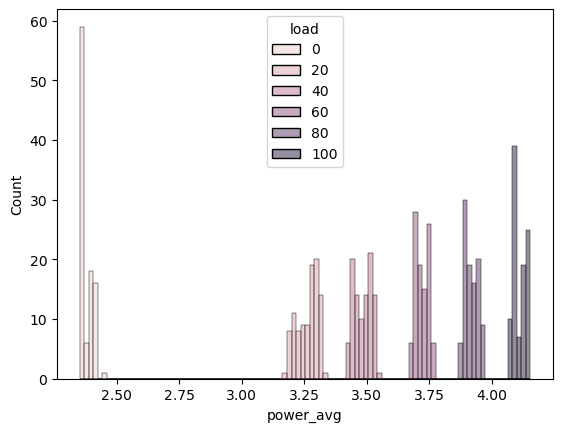

In [424]:
sns.histplot(data=dfs[(dfs['experiment']=='stress-ng')], x='power_avg', hue='load', bins=100)

In [486]:
dfs['N_loggings'] = np.where(
    dfs["period"] == 0.0,
    0,  # if period == 0.0 → 0 logs (no energy logging)
    (dfs["duration"] // dfs["period"])  # otherwise normal formula
)

In [649]:
dfs['energy_normalized'] = dfs['power_avg']*80
print(2.171e-05*800)
print(3.519e-05*800)

0.017368
0.028152


0                             OLS Regression Results                            
Dep. Variable:      energy_normalized   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     185.7
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           2.49e-22
Time:                        11:35:29   Log-Likelihood:                -97.128
No. Observations:                  80   AIC:                             198.3
Df Residuals:                      78   BIC:                             203.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    188.1907      0.133   1417.475      0

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/2539688267.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = result.params[0] + result.params[1] * x_range
/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/2539688267.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = result.params[0] + result.params[1] * x_range
/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/2539688267.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beh

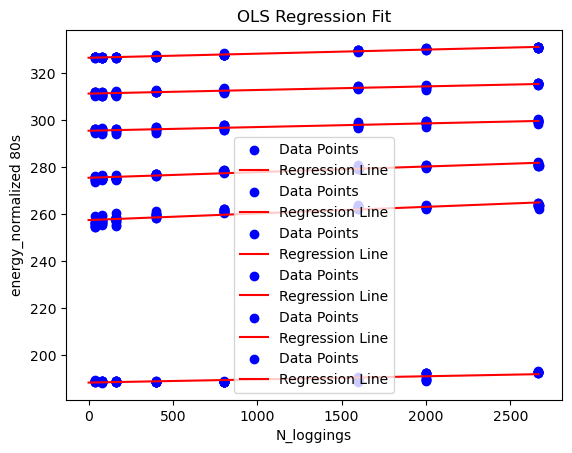

In [651]:
import statsmodels.api as sm 

for load_, data in dfs[(dfs['experiment']=='stress-ng') & (dfs['N_loggings']<3000)].groupby('load'):
    #x = data['N_loggings']  
    #y = data['power_avg']
    #result = sm.OLS(y, x).fit()
    result = smf.ols("energy_normalized ~ N_loggings ", data=data).fit()
    print(load_,result.summary())
      
    plt.scatter(data['N_loggings'], data['energy_normalized'], color='blue', label='Data Points')
    
    x_range = np.linspace(0, data['N_loggings'].max(), 100)
    y_pred = result.params[0] + result.params[1] * x_range 
    
    plt.plot(x_range, y_pred, color='red', label='Regression Line')
    plt.xlabel('N_loggings')
    plt.ylabel('energy_normalized 80s')
    plt.title('OLS Regression Fit')
    plt.legend()
plt.show()

 

<Axes: xlabel='N_loggings', ylabel='power_avg'>

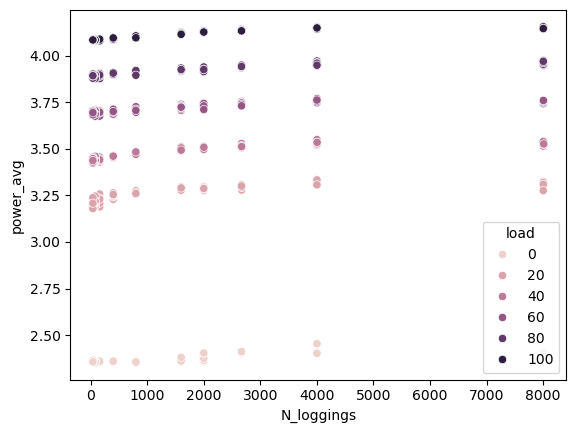

In [617]:
sns.scatterplot(data=dfs[(dfs['experiment']=='stress-ng')], hue='load', x='N_loggings', y='power_avg')

In [563]:
import pandas as pd

# 1) Compute baseline P0 per (experiment, load) from period == 0.0
baseline = (
    dfs[dfs["period"] == 0.0]
    .groupby(["experiment", "load"])["power_avg"]
    .mean()
    .rename("P0")
    .reset_index()
)

# 2) Attach P0 to all rows
dfs_with_P0 = dfs.merge(baseline, on=["experiment", "load"], how="left")

# 3) Compute overhead power and overhead ratio for each measurement
dfs_with_P0["power_overhead"] = dfs_with_P0["power_avg"] - dfs_with_P0["P0"]
dfs_with_P0["power_overhead_ratio"] = (
    dfs_with_P0["power_overhead"] / dfs_with_P0["P0"]
)

# (Optional) drop the baseline rows if you only care about periods > 0
dfs_overhead = dfs_with_P0[dfs_with_P0["period"] > 0.0]

# 4) For each period, get range of overhead across loads (and experiments)
range_per_period = (
    dfs_overhead
    .groupby("period")
    .agg(
        overhead_W_min=("power_overhead", "min"),
        overhead_W_max=("power_overhead", "max"),
        overhead_ratio_min=("power_overhead_ratio", "min"),
        overhead_ratio_max=("power_overhead_ratio", "max"),
    )
    .reset_index()
)

print(range_per_period)




   period  overhead_W_min  overhead_W_max  overhead_ratio_min  \
0    0.01        0.042030        0.050252            0.017812   
1    0.02        0.040322        0.048157            0.017088   
2    0.03        0.040831        0.097120            0.017304   
3    0.04        0.002036        0.047426            0.000863   
4    0.05        0.003346        0.033257            0.001418   
5    0.10       -0.009678        0.047138           -0.004101   
6    0.20       -0.007777        0.000961           -0.003296   
7    0.50       -0.007514        0.069550           -0.003185   
8    1.00       -0.007199        0.003850           -0.003051   
9    2.00       -0.003760        0.004866           -0.001593   

   overhead_ratio_max  
0            0.021296  
1            0.020408  
2            0.041158  
3            0.020099  
4            0.014094  
5            0.019977  
6            0.000407  
7            0.029474  
8            0.001632  
9            0.002062  


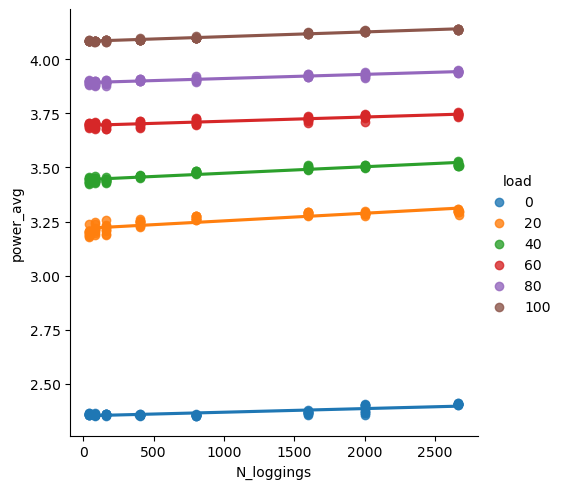

In [623]:
#for load_, df_load in dfs[(dfs['experiment']=='stress-ng') & (dfs['N_loggings']<3000)].groupby('load'):
sns.lmplot(data=dfs[(dfs['experiment']=='stress-ng') & (dfs['N_loggings']<3000)],x='N_loggings',y='power_avg',hue='load')

#sns.scatterplot(data=dfs[(dfs['experiment']=='stress-ng')], hue='load', x='N_loggings', y='power_avg')

In [506]:
import numpy as np
import pandas as pd

models = []

for (exp, load), sub in dfs[dfs["period"] > 0].groupby(["experiment", "load"]):
    # logging frequency = logs per second
    freq = 1.0 / sub["period"].values   # 1/period

    y = sub["power_avg"].values         # W = J/s

    # Fit: power_avg = P0 + E_log * freq
    slope, intercept = np.polyfit(freq, y, 1)

    models.append({
        "experiment": exp,
        "load": load,
        "P0": intercept,      # baseline power (no logging), W
        "E_log": slope        # energy per log, J
    })

models_df = pd.DataFrame(models)
print(models_df)


  experiment  load        P0     E_log
0      sleep     0  2.363180  0.000582
1  stress-ng     0  2.361498  0.000604
2  stress-ng    20  3.239034  0.001022
3  stress-ng    40  3.459973  0.000968
4  stress-ng    60  3.704612  0.000691
5  stress-ng    80  3.901127  0.000760
6  stress-ng   100  4.094311  0.000762


This model 

$power_{avg} ≈ P_0 + E_{log} \times \frac{1}{period}$

For example

sleep, load=0:
- Baseline ≈ 2.36 W
- Each logging call costs ≈ 0.000582 J = 0.582 mJ

stress-ng, load=100:
- Baseline ≈ 4.09 W
- Each logging call costs ≈ 0.000762 J = 0.762 mJ

Thus, for a given workload (experiment, load) and a logging period $p$ in seconds:
- Logging frequency: $f = 1/p$ logs per second
- Overhead power (W): $P_{overhead}(p) = f \times E_{log} =  E_{log} / p$
- Total power (W): $P(p)=P_0+E_{log}/p$


Therefore, given a run lasts $duration$ seconds, then:

- Baseline energy (no logging):$E_0=P_0\times duration$
- Energy with logging at period $p$: $E(p)=P(p)⋅duration=(P_0​+E_{log}/p)⋅duration$
- Energy overhead for logging in that period: $E_{overhead}(p)=E(p)−E_0 = \frac{E_log}{p}\ times duration$


In [518]:
def get_model_row(experiment, load, models_df):
    return models_df.query("experiment == @experiment and load == @load").iloc[0]

def predict_power(period, experiment, load, models_df):
    """
    period in seconds. period = 0.0 → no logging.
    returns predicted average power (W).
    """
    row = get_model_row(experiment, load, models_df)
    P0 = row["P0"]
    E_log = row["E_log"]
    
    if period == 0.0:
        return P0
    return P0 + E_log / period


def predict_energy(period, experiment, load, duration, models_df):
    """
    returns predicted total energy for the run (J).
    """
    P = predict_power(period, experiment, load, models_df)
    return P * duration


def predict_overhead(period, experiment, load, duration, models_df):
    """
    returns energy overhead for that period vs no logging (J).
    """
    row = get_model_row(experiment, load, models_df)
    P0 = row["P0"]
    E0 = P0 * duration
    E_period = predict_energy(period, experiment, load, duration, models_df)
    return E_period - E0


In [520]:
duration = 80.0  # or dfs.query("experiment=='stress-ng' & load==40")["duration"].mean()

exp = "stress-ng"
load = 40

for p in [0.01, 0.05, 0.1, 0.5, 1.0]:
    E_over = predict_overhead(p, exp, load, duration, models_df)
    print(f"period={p:4.2f} s → overhead = {E_over:.4f} J")


period=0.01 s → overhead = 7.7455 J
period=0.05 s → overhead = 1.5491 J
period=0.10 s → overhead = 0.7746 J
period=0.50 s → overhead = 0.1549 J
period=1.00 s → overhead = 0.0775 J


The energy-overhead ratio for a given period $p$ is:
$\frac{E_{overhead}}{E_0} = \frac{E_{log}/p}{P_0} = \frac{E_{log}}{p \times P_0}$



In [523]:
def power_overhead_ratio(period, experiment, load, models_df):
    """
    period: logging period in seconds
    returns: overhead ratio (e.g. 0.01 = 1 %)
    """
    row = models_df.query("experiment == @experiment and load == @load").iloc[0]
    P0 = row["P0"]
    E_log = row["E_log"]
    
    if period == 0.0:
        return 0.0  # no logging, no overhead
    
    return E_log / (P0 * period)


In [525]:
for p in [1.0, 0.5, 0.1, 0.05, 0.01]:
    r = power_overhead_ratio(p, "stress-ng", 40, models_df)
    print(f"period={p:4.2f}s → overhead={r*100:.3f}%")


period=1.00s → overhead=0.028%
period=0.50s → overhead=0.056%
period=0.10s → overhead=0.280%
period=0.05s → overhead=0.560%
period=0.01s → overhead=2.798%


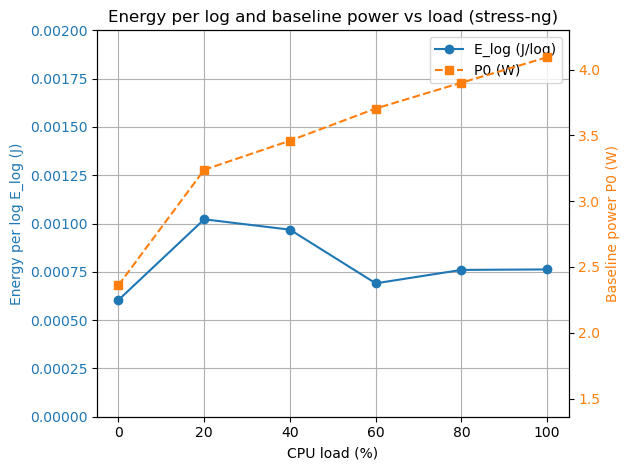

In [559]:
import matplotlib.pyplot as plt

stress = models_df[models_df["experiment"] == "stress-ng"]

fig, ax1 = plt.subplots()

# Colors
color_Elog = "tab:blue"
color_P0   = "tab:orange"

# Left y-axis: E_log
ax1.set_xlabel("CPU load (%)")
ax1.set_ylabel("Energy per log E_log (J)", color=color_Elog)
line1 = ax1.plot(
    stress["load"], stress["E_log"],
    marker="o",
    color=color_Elog,
    label="E_log (J/log)",
)
ax1.tick_params(axis="y", labelcolor=color_Elog)
ax1.grid(True)

# Right y-axis: P0
ax2 = ax1.twinx()
ax2.set_ylabel("Baseline power P0 (W)", color=color_P0)
line2 = ax2.plot(
    stress["load"], stress["P0"],
    marker="s",
    linestyle="--",
    color=color_P0,
    label="P0 (W)",
)
ax2.tick_params(axis="y", labelcolor=color_P0)

# 🔹 Make baseline power axis start at 0 W
max_P0 = stress["P0"].max()
ax2.set_ylim(stress["P0"].min()-1, max_P0 * 1.05)  # a little headroom above max

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")
#ax1.set_ylim(stress["E_log"].min()-0.01, stress["E_log"].max() +0.01) 
ax1.set_ylim(0, 0.002) 

plt.title("Energy per log and baseline power vs load (stress-ng)")
plt.tight_layout()
plt.show()


In [583]:
dfs

,period,load,exp_duration,experiment,duration,energy,power_avg,ID,N_logs,N_loggings
0,0.0,0,80015,sleep,80.009,188.507900,2.356084,53,inf,0.0
1,0.0,0,80015,sleep,80.007,188.831075,2.360182,160,inf,0.0
2,0.0,0,80015,sleep,80.010,188.753625,2.359125,171,inf,0.0
3,0.0,0,80015,sleep,80.011,188.826150,2.360002,206,inf,0.0
4,0.0,0,80015,sleep,80.008,189.072250,2.363167,224,inf,0.0
...,...,...,...,...,...,...,...,...,...,...
980,2.0,40,80022,stress-ng,80.019,274.392875,3.429097,947,40.0095,40.0
981,2.0,40,80022,stress-ng,80.015,275.052475,3.437511,955,40.0075,40.0
982,2.0,60,80024,stress-ng,80.015,294.686950,3.682896,970,40.0075,40.0
983,2.0,60,80023,stress-ng,80.018,295.631625,3.694564,978,40.0090,40.0


Stress rows used: 60


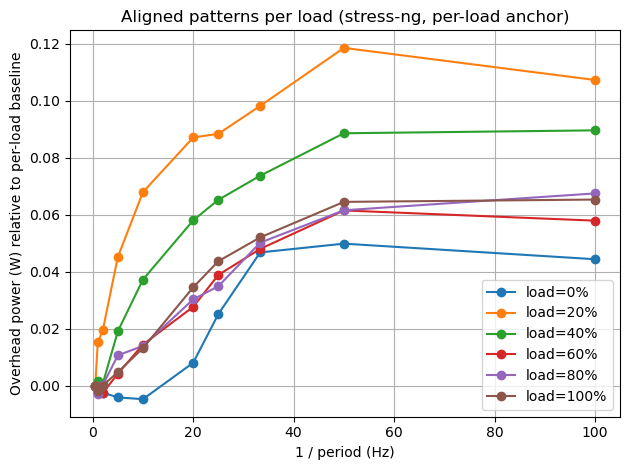

In [591]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Average power per (experiment, load, period)
agg = (
    dfs
    .groupby(["experiment", "load", "period"], as_index=False)["power_avg"]
    .mean()
    .rename(columns={"power_avg": "power_mean"})
)

# 2) Work only with stress-ng
stress_agg = agg[agg["experiment"] == "stress-ng"].copy()

# For each *load*, find the row with the largest period and use its *mean* power as anchor
idx = stress_agg.groupby("load")["period"].idxmax()
anchors = (
    stress_agg.loc[idx, ["load", "power_mean"]]
    .rename(columns={"power_mean": "P_base"})
)

# Attach per-load anchor
stress_agg = stress_agg.merge(anchors, on="load", how="left")

# Compute frequency and overhead relative to that per-load anchor
stress_agg["freq"] = 1.0 / stress_agg["period"]
stress_agg["overhead"] = stress_agg["power_mean"] - stress_agg["P_base"]


print("Stress rows used:", len(stress_agg))
plt.figure()
for load, sub in stress_agg.groupby("load"):
    plt.plot(
        sub["freq"],
        sub["overhead"],
        marker="o",
        label=f"load={load}%"
    )

plt.xlabel("1 / period (Hz)")
plt.ylabel("Overhead power (W) relative to per-load baseline")
plt.title("Aligned patterns per load (stress-ng, per-load anchor)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [593]:
agg = (
    dfs
    .groupby(["experiment", "load", "period"], as_index=False)["power_avg"]
    .mean()
    .rename(columns={"power_avg": "power_mean"})
)

stress = agg[agg["experiment"] == "stress-ng"].copy()
stress["freq"] = 1.0 / stress["period"]  # Hz

stress_model = stress[stress["freq"] <= 50].copy()  # keep ≤ 50 Hz

from scipy.optimize import curve_fit

def sat_model(f, P0, A, B):
    return P0 + A * f / (1.0 + B * f)

models_sat = []

for (exp, load), sub in stress.groupby(["experiment", "load"]):
    f = sub["freq"].values
    y = sub["power_mean"].values

    # initial guesses
    p0 = [y.min(), 0.001, 0.01]

    popt, _ = curve_fit(sat_model, f, y, p0=p0, maxfev=10000)
    P0_fit, A_fit, B_fit = popt

    models_sat.append({
        "experiment": exp,
        "load": load,
        "P0_sat": P0_fit,
        "A": A_fit,
        "B": B_fit,
    })

models_sat_df = pd.DataFrame(models_sat)
print(models_sat_df)



  experiment  load    P0_sat         A         B
0  stress-ng     0  2.352426  0.002034  0.023041
1  stress-ng    20  3.194790  0.016533  0.129142
2  stress-ng    40  3.433390  0.007305  0.061677
3  stress-ng    60  3.690658  0.003327  0.036916
4  stress-ng    80  3.888827  0.002915  0.028491
5  stress-ng   100  4.079086  0.003652  0.036873


In [597]:


def P_overhead_saturating(period, P0_sat, A, B):
    """
    period in seconds
    returns (P_total, P_overhead, overhead_ratio)
    """
    if period == 0.0:
        # no logging
        P_total = P0_sat
        P_over = 0.0
    else:
        f = 1.0 / period  # Hz
        P_over = A * f / (1.0 + B * f)
        P_total = P0_sat + P_over
    overhead_ratio = P_over / P0_sat  # fraction
    return P_total, P_over, overhead_ratio
    
row = models_sat_df.query("experiment == 'stress-ng' and load == 40").iloc[0]
P0_sat, A, B = row["P0_sat"], row["A"], row["B"]

for period in [1.0, 0.5, 0.2, 0.1, 0.05]:
    P_tot, P_over, r = P_overhead_saturating(period, P0_sat, A, B)
    print(f"period={period:4.2f}s  P_over={P_over:.4f} W  overhead={r*100:.2f}%")


period=1.00s  P_over=0.0069 W  overhead=0.20%
period=0.50s  P_over=0.0130 W  overhead=0.38%
period=0.20s  P_over=0.0279 W  overhead=0.81%
period=0.10s  P_over=0.0452 W  overhead=1.32%
period=0.05s  P_over=0.0654 W  overhead=1.91%


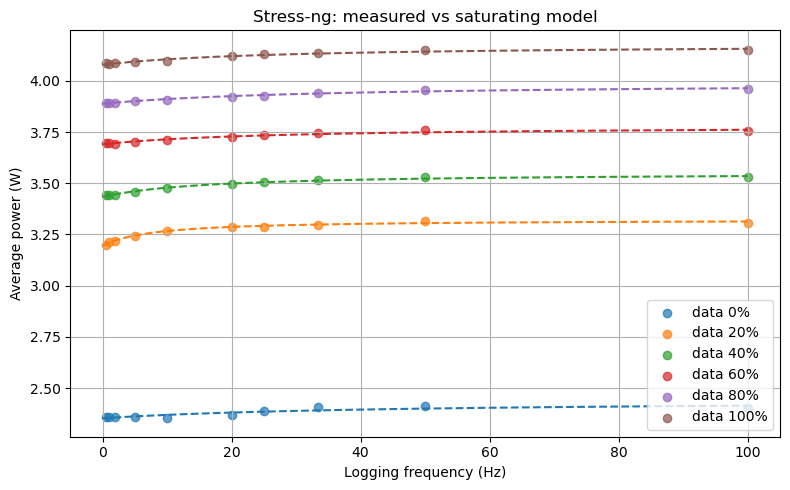

  experiment  load    P0_sat         A         B
0  stress-ng     0  2.352426  0.002034  0.023041
1  stress-ng    20  3.194790  0.016533  0.129142
2  stress-ng    40  3.433390  0.007305  0.061677
3  stress-ng    60  3.690658  0.003327  0.036916
4  stress-ng    80  3.888827  0.002915  0.028491
5  stress-ng   100  4.079086  0.003652  0.036873


In [607]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Average power per (experiment, load, period) ---
agg = (
    dfs
    .groupby(["experiment", "load", "period"], as_index=False)["power_avg"]
    .mean()
    .rename(columns={"power_avg": "power_mean"})
)

# Focus on stress-ng
stress = agg[agg["experiment"] == "stress-ng"].copy()
stress["freq"] = 1.0 / stress["period"]  # Hz

# --- 2) Define the saturating model ---
def sat_model(f, P0, A, B):
    """Saturating model: P(f) = P0 + A f / (1 + B f)"""
    return P0 + A * f / (1.0 + B * f)

# --- 3) Plot measured vs model for all loads ---
plt.figure(figsize=(8, 5))

# Limit to a sensible frequency range (e.g. up to 50 Hz), to avoid 100 Hz weirdness
f_min, f_max = 0, 100
freq_grid = np.linspace(f_min, f_max, 300)

for load, sub in stress.groupby("load"):
    # Measured points (averaged)
    sub_in_range = sub[sub["freq"] <= f_max]

    plt.scatter(
        sub_in_range["freq"],
        sub_in_range["power_mean"],
        alpha=0.7,
        label=f"data {load}%",
    )

    # Model curve for this load
    row = models_sat_df.query("experiment == 'stress-ng' and load == @load").iloc[0]
    P0_sat, A, B = row["P0_sat"], row["A"], row["B"]
    P_model = sat_model(freq_grid, P0_sat, A, B)

    plt.plot(
        freq_grid,
        P_model,
        linestyle="--",
    )

plt.xlabel("Logging frequency (Hz)")
plt.ylabel("Average power (W)")
plt.title("Stress-ng: measured vs saturating model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(models_sat_df)


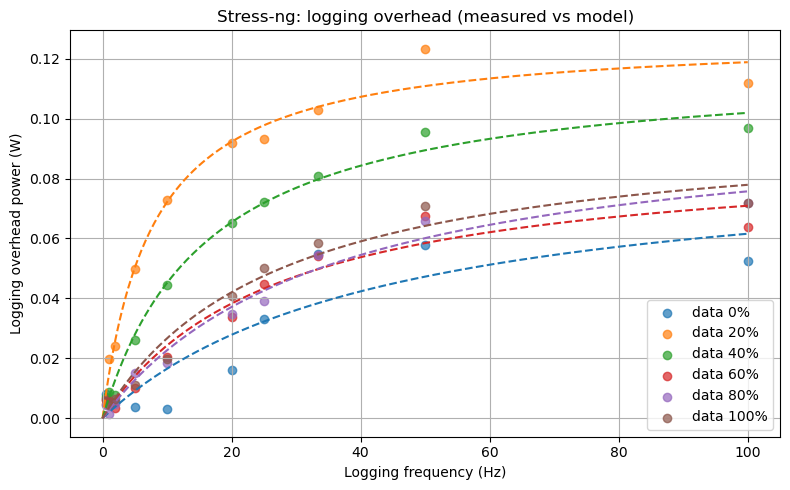

In [605]:
plt.figure(figsize=(8, 5))

for load, sub in stress.groupby("load"):
    sub_in_range = sub[sub["freq"] <= f_max]

    # Grab model params
    row = models_sat_df.query("experiment == 'stress-ng' and load == @load").iloc[0]
    P0_sat, A, B = row["P0_sat"], row["A"], row["B"]

    # Measured overhead relative to model baseline
    overhead_meas = sub_in_range["power_mean"] - P0_sat

    plt.scatter(
        sub_in_range["freq"],
        overhead_meas,
        alpha=0.7,
        label=f"data {load}%",
    )

    # Model overhead curve
    P_model = sat_model(freq_grid, P0_sat, A, B)
    overhead_model = P_model - P0_sat
    plt.plot(
        freq_grid,
        overhead_model,
        linestyle="--",
    )

plt.xlabel("Logging frequency (Hz)")
plt.ylabel("Logging overhead power (W)")
plt.title("Stress-ng: logging overhead (measured vs model)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


A_avg = 0.00503481, B_avg = 0.0497283
Max saturated overhead ≈ 0.1012 W


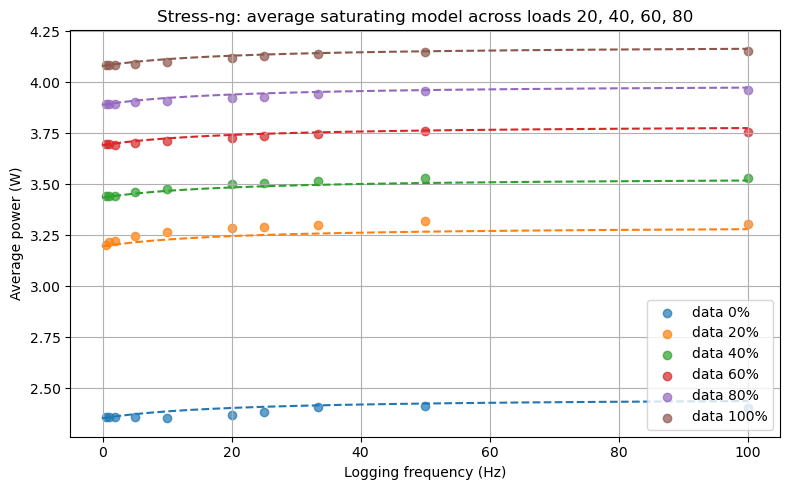

In [613]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1) Average power per (experiment, load, period) ---
agg = (
    dfs
    .groupby(["experiment", "load", "period"], as_index=False)["power_avg"]
    .mean()
    .rename(columns={"power_avg": "power_mean"})
)

# Focus on stress-ng and add frequency
stress = agg[agg["experiment"] == "stress-ng"].copy()
stress["freq"] = 1.0 / stress["period"]  # Hz

# Merge in per-load P0_sat from your saturating fits
stress = stress.merge(
    models_sat_df[["experiment", "load", "P0_sat"]],
    on=["experiment", "load"],
    how="left"
)

# The loads to include in the average model
loads_to_use = [0,20, 40, 60, 80, 100]

sub = stress[stress["load"].isin(loads_to_use)].copy()

# Compute overhead relative to per-load P0_sat
sub["overhead"] = sub["power_mean"] - sub["P0_sat"]

# Use all points (you *can* restrict freq if you want to ignore extreme 100Hz artefacts)
f_all = sub["freq"].values
over_all = sub["overhead"].values

# Limit to a sensible frequency range (e.g. up to 50 Hz), to avoid 100 Hz weirdness
#f_min, f_max = 0, 100
#freq_grid = np.linspace(f_min, f_max, 300)


def sat_overhead(f, A, B):
    return A * f / (1.0 + B * f)

# Initial guess from your earlier per-load fits (rough scale)
p0 = [0.005, 0.05]

(A_avg, B_avg), pcov = curve_fit(sat_overhead, f_all, over_all, p0=p0, maxfev=10000)

print(f"A_avg = {A_avg:.6g}, B_avg = {B_avg:.6g}")
print(f"Max saturated overhead ≈ {A_avg / B_avg:.4f} W")

# Average model:
# P(f, load) = P0_sat(load) + A_avg * f / (1 + B_avg * f)

plt.figure(figsize=(8, 5))

f_min, f_max = 0, 100
freq_grid = np.linspace(f_min, f_max, 300)

for load, g in sub.groupby("load"):
    # measured points
    plt.scatter(
        g["freq"], g["power_mean"],
        alpha=0.7,
        label=f"data {load}%",
    )

    # model curve for this load with *shared* A_avg,B_avg, but its own P0_sat
    P0 = g["P0_sat"].iloc[0]
    P_model = P0 + sat_overhead(freq_grid, A_avg, B_avg)

    plt.plot(
        freq_grid,
        P_model,
        linestyle="--",
    )

plt.xlabel("Logging frequency (Hz)")
plt.ylabel("Average power (W)")
plt.title("Stress-ng: average saturating model across loads 20, 40, 60, 80")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [567]:
# Do they show the same: 

import numpy as np

# 1) Baseline from measurements
baseline = (
    dfs[dfs["period"] == 0.0]
    .groupby(["experiment", "load"])["power_avg"]
    .mean()
    .rename("P0_data")
    .reset_index()
)

dfs_with = dfs.merge(baseline, on=["experiment", "load"], how="left")

# 2) Overhead from data
dfs_with["power_overhead_data"] = dfs_with["power_avg"] - dfs_with["P0_data"]

# 3) Attach model P0 and E_log
dfs_with = dfs_with.merge(models_df, on=["experiment", "load"], how="left",
                          suffixes=("_data", "_model"))

# 4) Overhead from model (for period > 0)
dfs_with["power_overhead_model"] = np.where(
    dfs_with["period"] > 0,
    dfs_with["E_log"] / dfs_with["period"],
    0.0
)

# 5) Compare
dfs_compare = dfs_with[dfs_with["period"] > 0][
    ["experiment", "load", "period",
     "power_overhead_data", "power_overhead_model"]
]

print(dfs_compare.head())

# Optional: compute error stats
diff = dfs_compare["power_overhead_data"] - dfs_compare["power_overhead_model"]
print("Mean diff (W):", diff.mean())
print("Max abs diff (W):", diff.abs().max())


   experiment  load  period  power_overhead_data  power_overhead_model
35      sleep     0    0.01             0.048690              0.058186
36      sleep     0    0.01             0.043969              0.058186
37      sleep     0    0.01             0.044222              0.058186
38      sleep     0    0.01             0.046935              0.058186
39      sleep     0    0.01             0.043190              0.058186
Mean diff (W): 0.0035018799619421603
Max abs diff (W): 0.0777250070022003


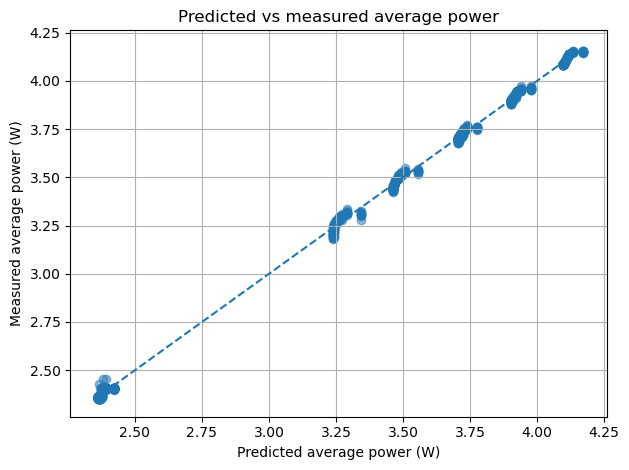

In [575]:
import numpy as np
import matplotlib.pyplot as plt

# Merge model parameters
dfs_m = dfs.merge(models_df, on=["experiment", "load"], how="left")

# Only periods > 0 (model is defined there)


dfs_m = dfs_m[dfs_m["period"] > 0].copy()

# Predicted power from the model
dfs_m["power_pred"] = dfs_m["P0"] + dfs_m["E_log"] / dfs_m["period"]

plt.figure()
plt.scatter(dfs_m["power_pred"], dfs_m["power_avg"], alpha=0.5)
plt.xlabel("Predicted average power (W)")
plt.ylabel("Measured average power (W)")
plt.title("Predicted vs measured average power")

# y = x reference line
lo = min(dfs_m["power_pred"].min(), dfs_m["power_avg"].min())
hi = max(dfs_m["power_pred"].max(), dfs_m["power_avg"].max())
plt.plot([lo, hi], [lo, hi], "--")

plt.grid(True)
plt.tight_layout()
plt.show()



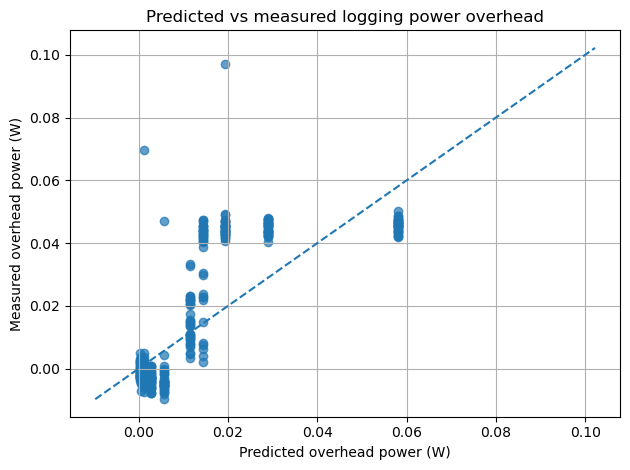

In [571]:
import matplotlib.pyplot as plt

x = dfs_compare["power_overhead_model"]   # predicted
y = dfs_compare["power_overhead_data"]    # measured

plt.figure()

plt.scatter(x, y, alpha=0.7)
plt.xlabel("Predicted overhead power (W)")
plt.ylabel("Measured overhead power (W)")
plt.title("Predicted vs measured logging power overhead")

# y = x reference line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.grid(True)
plt.tight_layout()
plt.show()


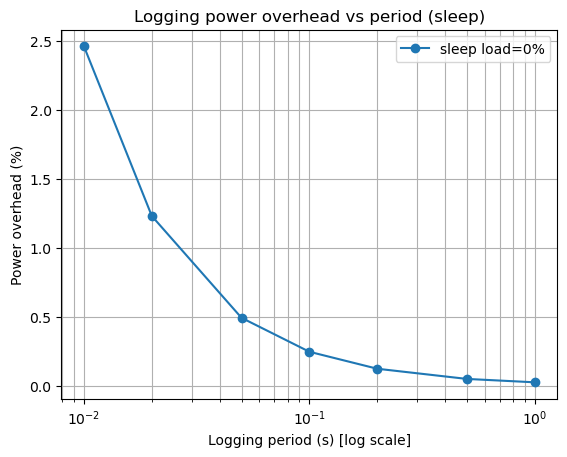

In [533]:
sleep = models_df[models_df["experiment"] == "sleep"]

plt.figure()

for _, row in sleep.iterrows():
    ratios = power_overhead_ratio(periods, row["P0"], row["E_log"])
    plt.plot(periods, ratios * 100, marker="o", label=f"sleep load={row['load']}%")

plt.xscale("log")
plt.xlabel("Logging period (s) [log scale]")
plt.ylabel("Power overhead (%)")
plt.title("Logging power overhead vs period (sleep)")
plt.legend()
plt.grid(True, which="both")
plt.show()


/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/4261282509.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')


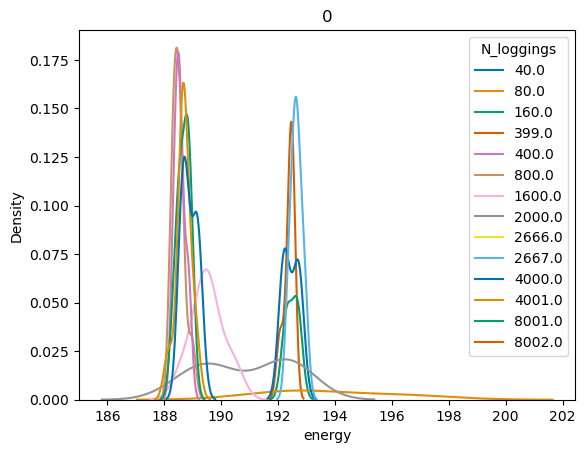

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/4261282509.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')


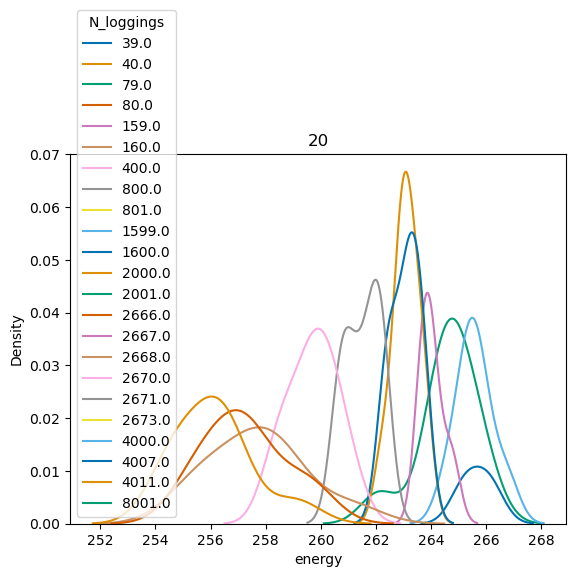

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/4261282509.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')


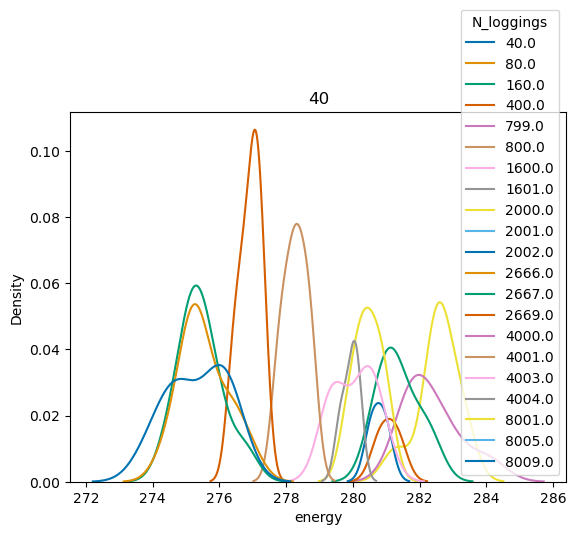

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/4261282509.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')


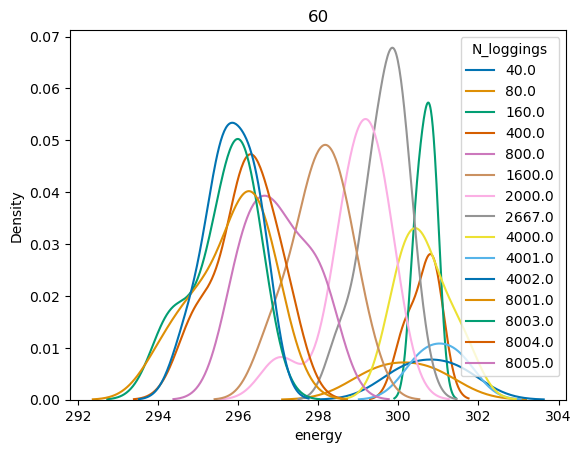

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/4261282509.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')


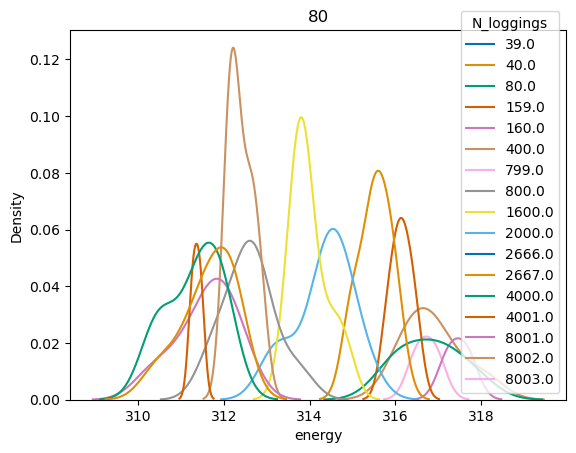

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_90579/4261282509.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')


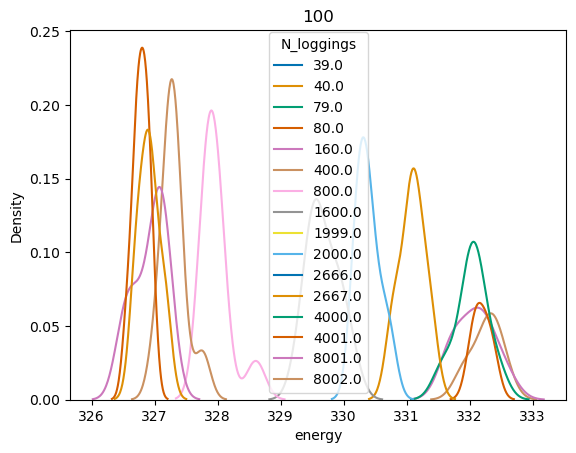

In [490]:
for l,df in dfs[(dfs['experiment']=='stress-ng')].groupby('load'):
    sns.kdeplot(data=df, x='energy', hue='N_loggings',palette='colorblind')
    plt.title(str(l))
    plt.show()

In [ ]:
sns.ll

<Axes: xlabel='period', ylabel='energy'>

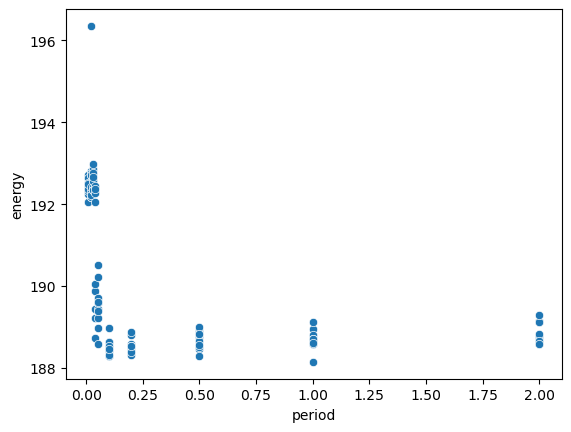

In [408]:
sns.scatterplot(data=dfs[(dfs['experiment']=='stress-ng') & (dfs['load']==0) ], x='period',y='energy')

<Axes: xlabel='period', ylabel='power_mean'>

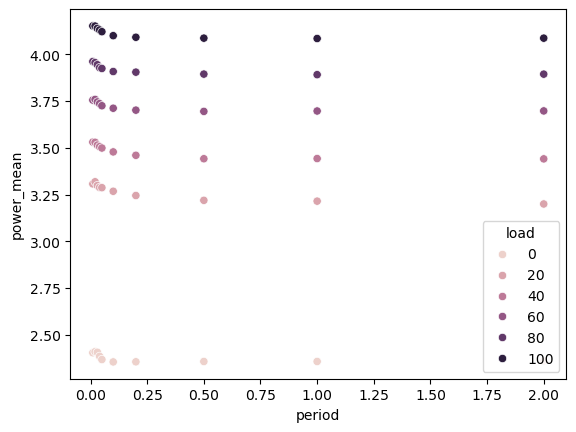

In [402]:
sns.scatterplot(data=pl_summary[pl_summary['experiment']=='stress-ng'], x='period',y='power_mean', hue='load')

<Axes: xlabel='period', ylabel='power_mean'>

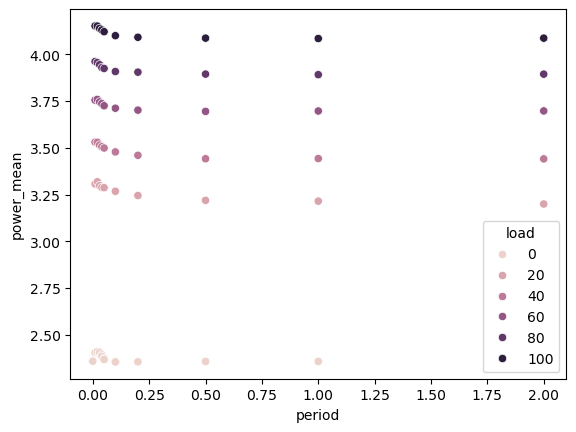

In [390]:
sns.scatterplot(data=pl_summary, x='period',y='power_mean', hue='load')

In [367]:
df_powers = pd.concat(list_of_dataframes)

In [368]:
df_powers = df_powers.reset_index(drop=True)

In [369]:
df_powers

,timestamp,channel,action,payload,time,ID,experiment,period
0,1764793124328,CH1,POWER,2.4,0.000,0,sleep,0.04
1,1764793124333,CH1,POWER,2.4,0.005,0,sleep,0.04
2,1764793124338,CH1,POWER,2.4,0.010,0,sleep,0.04
3,1764793124343,CH1,POWER,2.4,0.015,0,sleep,0.04
4,1764793124348,CH1,POWER,2.4,0.020,0,sleep,0.04
...,...,...,...,...,...,...,...,...
13961201,1764876358454,CH1,POWER,3.7,79.999,984,stress-ng,0.03
13961202,1764876358459,CH1,POWER,3.7,80.004,984,stress-ng,0.03
13961203,1764876358463,CH1,POWER,3.7,80.008,984,stress-ng,0.03
13961204,1764876358467,CH1,POWER,3.7,80.012,984,stress-ng,0.03


# Nilma and Jespers Evaluation

The above imports the chunked data and provides us with two dataframes:
- dfs which holds the energy data for all the test
- df_powers holds all the power measurements for all the tests

1. Ultimately, we want to find out how much energy the raspberry pi is using per tick. 
2. We need to verify whether we can trust the data. 

['sleep' 'stress-ng']


<Axes: xlabel='period', ylabel='energy'>

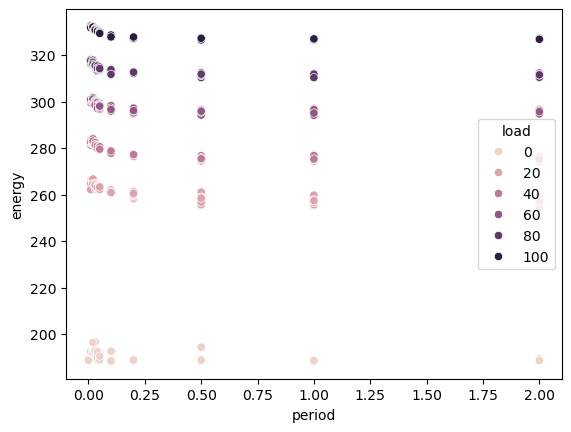

In [384]:
# first, we want to know how much energy is used for each number_of_messages
print(dfs['experiment'].unique())
sns.scatterplot(data= dfs, x='period',y='energy',hue='load',markers='experiment')

<Axes: xlabel='period', ylabel='power_avg'>

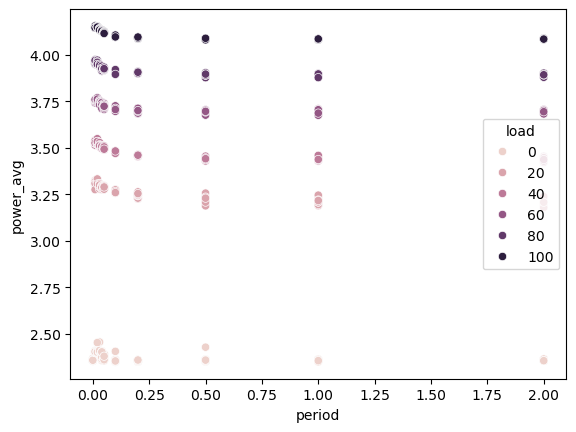

In [386]:
sns.scatterplot(data= dfs, x='period',y='power_avg',hue='load',markers='experiment')

<Axes: xlabel='time', ylabel='payload'>

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


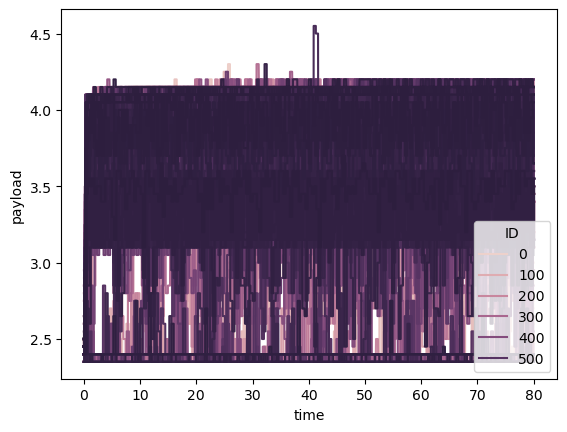

In [99]:
sns.lineplot(data=df_powers, x='time', y='payload',hue= 'ID')

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


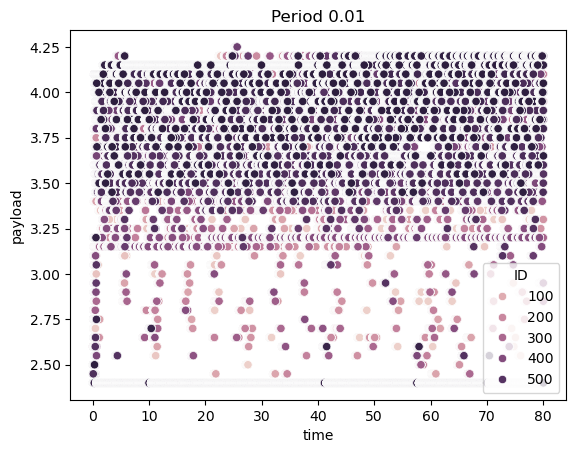

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


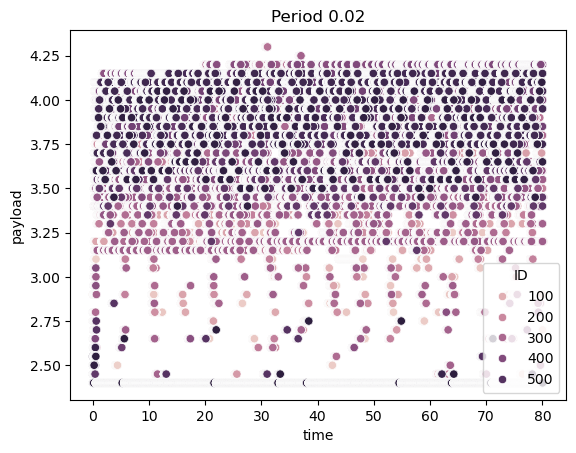

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


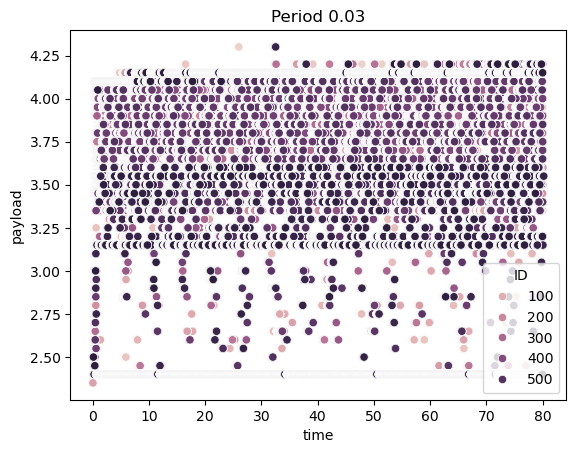

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


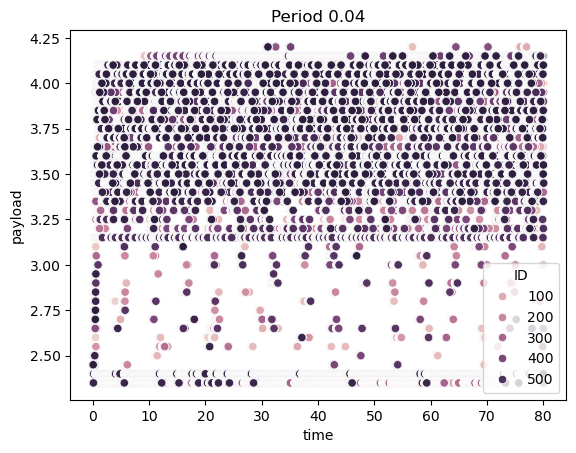

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


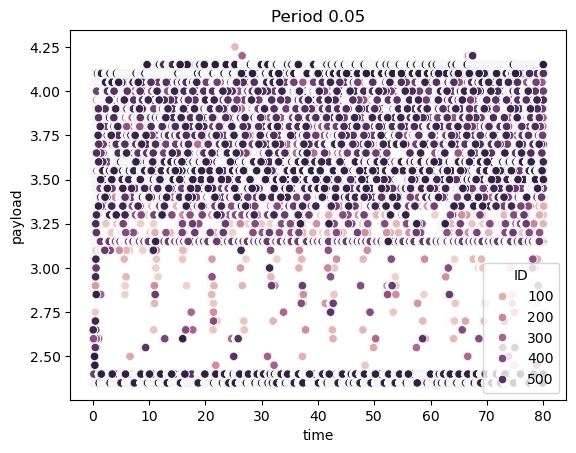

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


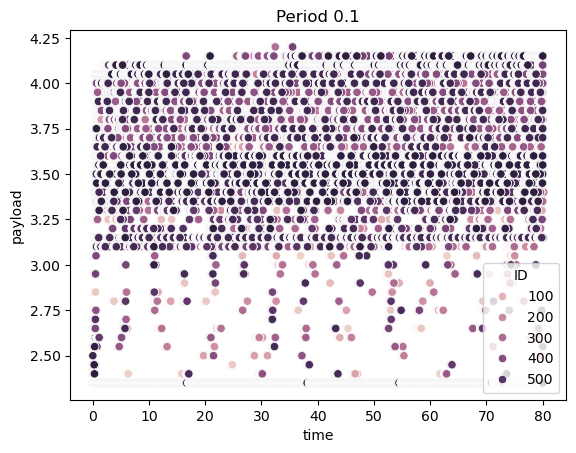

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


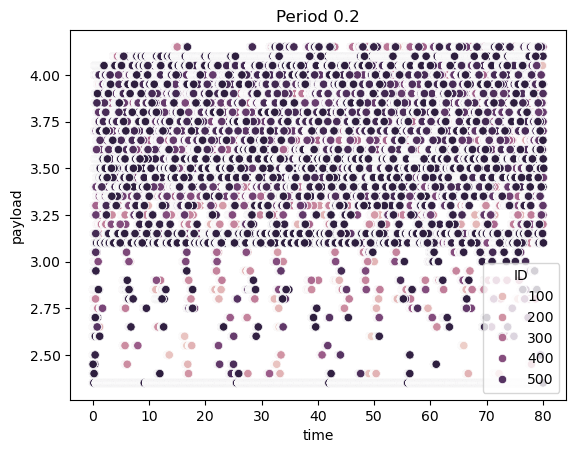

KeyboardInterrupt: 

In [105]:
df_powers_groupbytest = df_powers.groupby('period')

for test_, df in df_powers_groupbytest:
    sns.scatterplot(data=df, x='time', y='payload',hue= 'ID')
    plt.title(f"Period {test_}")
    plt.show()

In [ ]:
sns.scatterplot(data=df_powers, x='timestamp', y='payload',hue= 'period')

In [106]:
dfs.to_csv(output_directory+"sigless_energy_summary.csv")


### The Best-fit Global Model

$\text{energy} = a \cdot \text{number of messages} + b$

- $a$: baseline slope (effect of sending a message).
- $b$: global intercept (baseline energy when number of messages = 0).

R-squared (R²) is defined as a number that tells you how well the independent variable(s) in a statistical model explains the variation in the dependent variable. It ranges from 0 to 1, where 1 indicates a perfect fit of the model to the data.

While R² is often between 0 and 1, it can be negative when the model performs worse than predicting the mean of the data.

In [43]:
dfs= dfs[dfs['energy']<200]

                            OLS Regression Results                            
Dep. Variable:                 energy   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     677.6
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           1.34e-12
Time:                        10:03:21   Log-Likelihood:                -7.5278
No. Observations:                  15   AIC:                             19.06
Df Residuals:                      13   BIC:                             20.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        189.0883      0.154   1226.

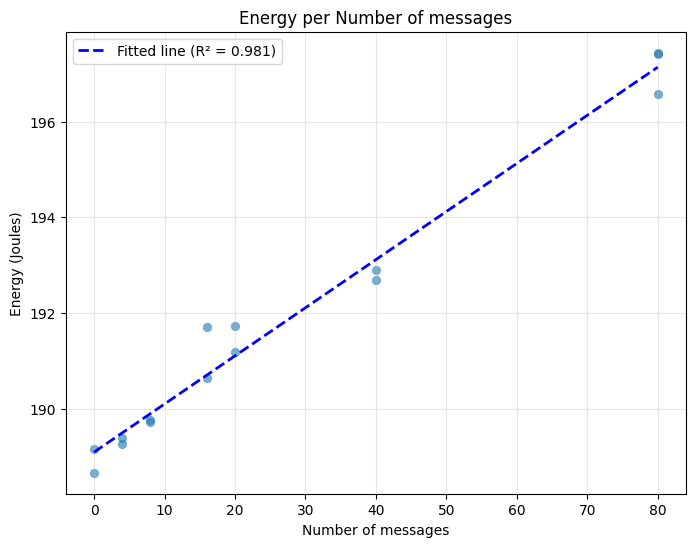

In [44]:
model = smf.ols("energy ~ no_of_messages", data=dfs).fit()
print(model.summary())

# Scatterplot of error vs duration
plt.figure(figsize=(8,6))
sns.scatterplot(x="no_of_messages", y="energy", data=dfs, alpha=0.6, edgecolor=None)

# Regression line (from statsmodels fit)
x_vals = np.linspace(dfs["no_of_messages"].min(), dfs["no_of_messages"].max(), 200)
y_vals = model.params['Intercept'] + model.params['no_of_messages']*x_vals  # from the regression model

r2_text = f"Fitted line (R² = {model.rsquared:.3f})"
plt.plot(x_vals, y_vals, color="blue", linewidth=2, linestyle='--',label=r2_text)

plt.title("Energy per Number of messages")
plt.xlabel("Number of messages")
plt.ylabel("Energy (Joules)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(output_directory+'energy_pr_no_of_message.png')
plt.show()